# Dataset EDA

Dataset-level GTEx/AHBA coverage, demographic, and pre/post harmonization diagnostics.


## Table of Contents

- 1) Dataset Attributes
- GTEx Demographics
- 2) Pre/Post ComBat Diagnostics


In [1]:
from pathlib import Path
import sys
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists() and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.eval_utils.eda_core import *


In [2]:
import importlib
import src.eval_utils.eda_core as eda_core
importlib.reload(eda_core)
from src.eval_utils.eda_core import *


In [3]:
set_academic_style()

CFG = EDAConfig(
    csv_path='data/raw/gxp_samples.csv',
    cache_root='out/loro_subject_cache_cv',  # 'out/loro_subject_cache_c' (centroids) | 'out/loro_subject_cache_cv' (centroids_and_volumes)
    gene_scope='allgenes',
)
CFG
print('analysis scope:', CFG.gene_scope)

analysis scope: allgenes


## 1) Dataset Attributes


In [4]:
PREPOST = prepare_pre_post_harmonization_cached(CFG)
print('subjects:', len(PREPOST['subjects']))
print('genes:', len(PREPOST['genes']))
print('parcels:', PREPOST['raw_cube'].shape[1])


[prepost_cache] hit  notebooks/cache/prepost/0f8616c23cf88e0f.pkl  (8961.2 MB)
subjects: 318
genes: 11704
parcels: 150


In [5]:
PREPOST

{'subjects': ['GTEX-1117F',
  'GTEX-111FC',
  'GTEX-117XS',
  'GTEX-1192W',
  'GTEX-1192X',
  'GTEX-11DXW',
  'GTEX-11DXY',
  'GTEX-11DYG',
  'GTEX-11DZ1',
  'GTEX-11EI6',
  'GTEX-11EMC',
  'GTEX-11GS4',
  'GTEX-11GSO',
  'GTEX-11GSP',
  'GTEX-11H98',
  'GTEX-11NUK',
  'GTEX-11NV4',
  'GTEX-11O72',
  'GTEX-11OF3',
  'GTEX-11ONC',
  'GTEX-11PRG',
  'GTEX-11TTK',
  'GTEX-11UD1',
  'GTEX-11WQC',
  'GTEX-11ZTS',
  'GTEX-11ZU8',
  'GTEX-11ZUS',
  'GTEX-11ZVC',
  'GTEX-12126',
  'GTEX-12WSA',
  'GTEX-12WSC',
  'GTEX-12WSD',
  'GTEX-12WSE',
  'GTEX-12WSF',
  'GTEX-12WSH',
  'GTEX-12WSM',
  'GTEX-12ZZW',
  'GTEX-12ZZX',
  'GTEX-12ZZY',
  'GTEX-12ZZZ',
  'GTEX-13112',
  'GTEX-1313W',
  'GTEX-131XH',
  'GTEX-131XW',
  'GTEX-131YS',
  'GTEX-132Q8',
  'GTEX-1399T',
  'GTEX-139T8',
  'GTEX-139TS',
  'GTEX-139TT',
  'GTEX-13CF2',
  'GTEX-13CZV',
  'GTEX-13FHO',
  'GTEX-13FHP',
  'GTEX-13FLV',
  'GTEX-13FLW',
  'GTEX-13FXS',
  'GTEX-13G51',
  'GTEX-13JUV',
  'GTEX-13JVG',
  'GTEX-13N1W',
  'GTEX-13N2

## GTEx Demographics

GTEx rows are donor-tissue samples, so demographic counts are collapsed to one row per subject before plotting.


,subject,age,sex
0,GTEX-1117F,64.0,F
1,GTEX-111FC,64.0,M
2,GTEX-1128S,64.0,F
3,GTEX-117XS,64.0,M
4,GTEX-117YW,54.0,M


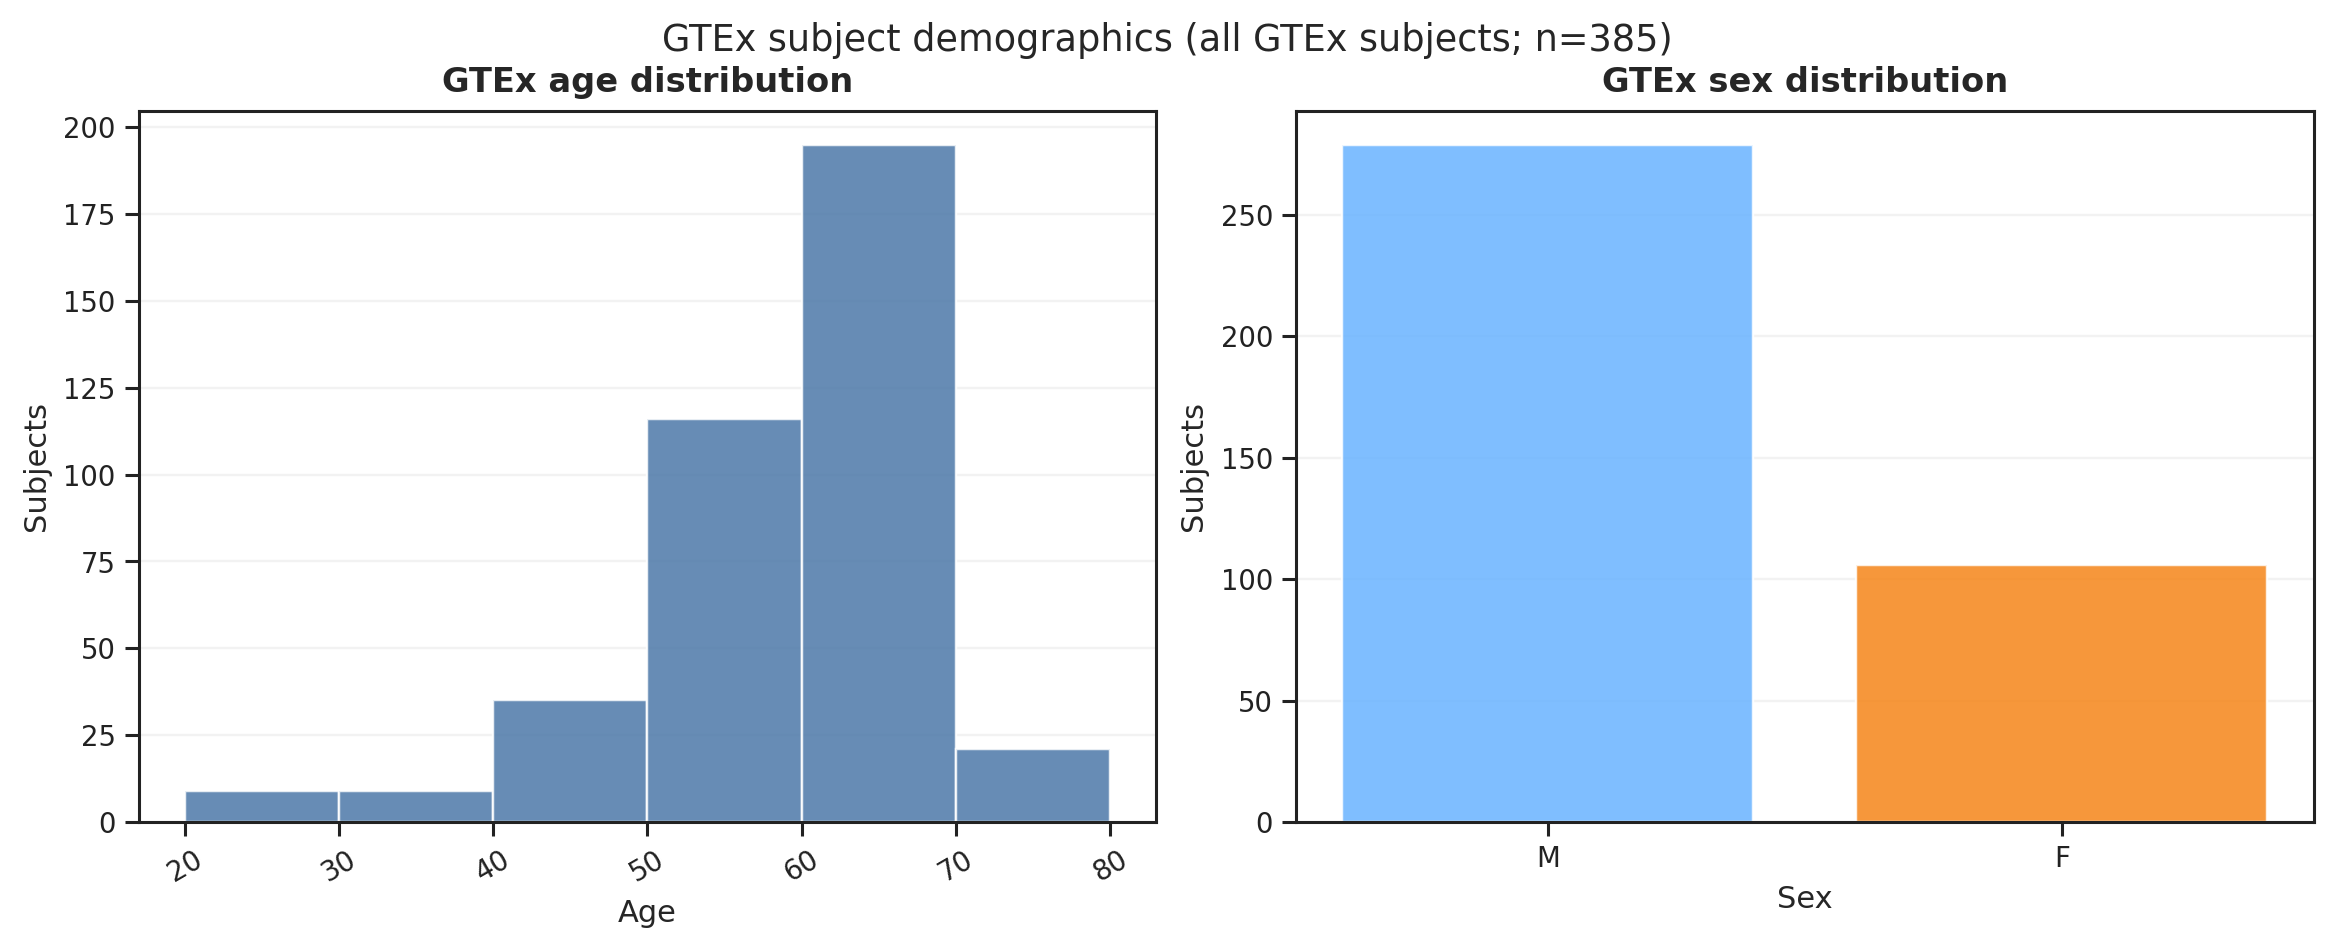

In [6]:
fig, axes, gtex_demo_df = plot_gtex_demographic_breakdown(PREPOST, eligible_only=False)
display(gtex_demo_df.head())


,subject,age,sex
0,GTEX-1117F,64.0,F
1,GTEX-111FC,64.0,M
2,GTEX-117XS,64.0,M
3,GTEX-1192W,64.0,M
4,GTEX-1192X,54.0,M


Subjects per age bin:
age
24.0      8
34.0      9
44.0     29
54.0     97
64.0    161
74.0     14
Name: count, dtype: Int64

Subjects per sex bin:
sex
F     82
M    236
Name: count, dtype: Int64


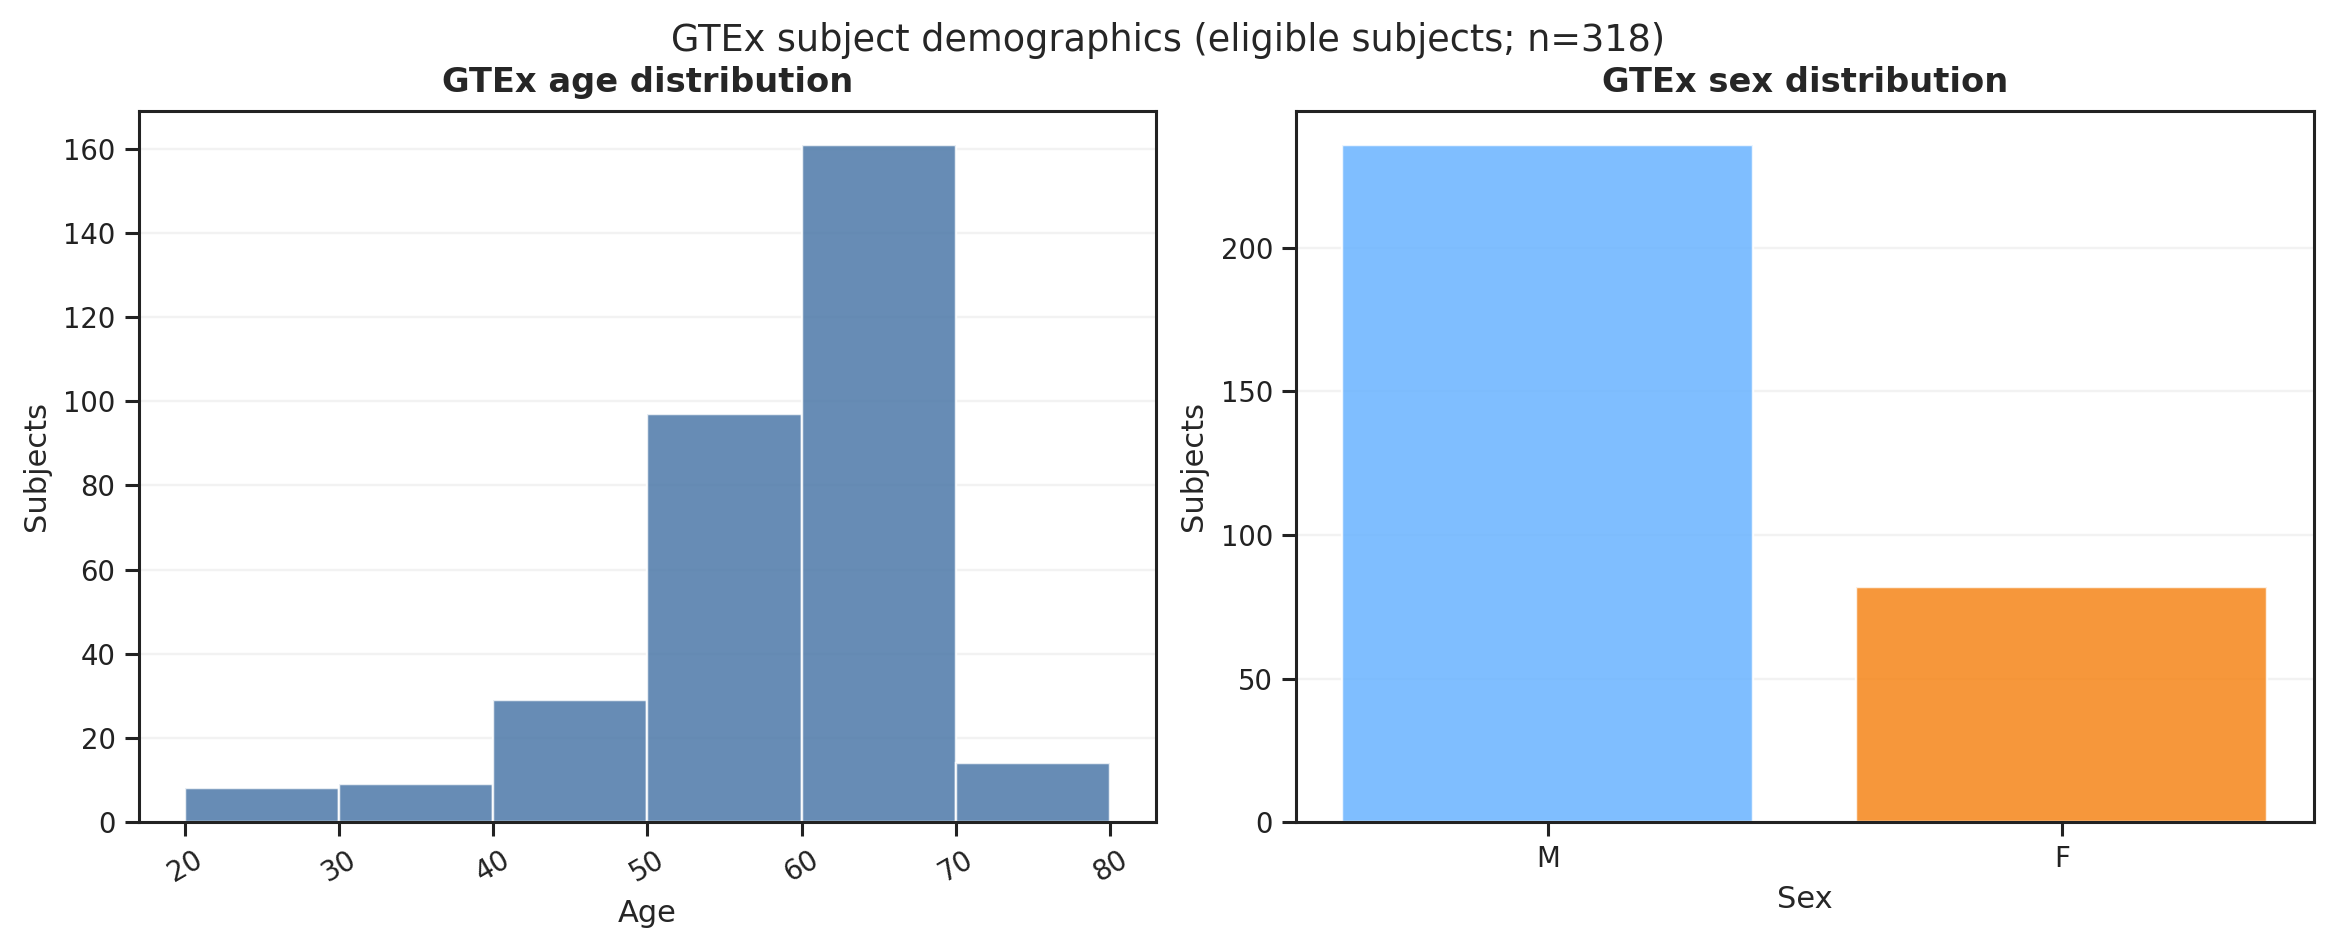

In [7]:
fig, axes, gtex_demo_df = plot_gtex_demographic_breakdown(PREPOST, eligible_only=True)
display(gtex_demo_df.head())

# Print number of subjects per age bin
age_bin_counts = gtex_demo_df['age'].value_counts(dropna=False).sort_index()
print("Subjects per age bin:")
print(age_bin_counts)

# Print number of subjects per sex bin
sex_bin_counts = gtex_demo_df['sex'].value_counts(dropna=False).sort_index()
print("\nSubjects per sex bin:")
print(sex_bin_counts)

In [8]:
# label_mode: 'ahba' | 'gtex' | 'both'
LABEL_MODE = 'both'
ELIGIBLE_ONLY = True

count_df = parcel_subject_count_table(PREPOST, label_mode=LABEL_MODE, eligible_only=ELIGIBLE_ONLY)
n_pool = int(count_df['n_subjects_pool'].iloc[0])
print(f'n (subjects in pool) = {n_pool}; eligible_only={ELIGIBLE_ONLY}')
count_df[['parcel_idx','ahba_parcel','gtex_native','n_subjects_observed','n_samples','label']].head(12)


n (subjects in pool) = 318; eligible_only=True


,parcel_idx,ahba_parcel,gtex_native,n_subjects_observed,n_samples,label
0,10,LH-Ca,caudate (basal ganglia),279,279,LH-Ca: caudate (basal ganglia)
1,18,LH-NAC,nucleus accumbens (basal ganglia),273,273,LH-NAC: nucleus accumbens (basal ganglia)
2,4,Cerebellar_Region4,cerebellar hemisphere,262,262,Cerebellar_Region4: cerebellar hemisphere
3,64,LH_SalVentAttn_PFCl_1,frontal cortex (ba9),252,252,LH_SalVentAttn_PFCl_1: frontal cortex (ba9)
4,7,Cerebellar_Region7,cerebellum,251,251,Cerebellar_Region7: cerebellum
5,19,LH-Pu,putamen (basal ganglia),250,250,LH-Pu: putamen (basal ganglia)
6,16,LH-HTH,hypothalamus,242,242,LH-HTH: hypothalamus
7,37,LH_Default_PFC_4,cortex,240,240,LH_Default_PFC_4: cortex
8,55,LH_Hippocampus,hippocampus,240,240,LH_Hippocampus: hippocampus
9,61,LH_SalVentAttn_Med_1,anterior cingulate cortex (ba24),223,223,LH_SalVentAttn_Med_1: anterior cingulate corte...


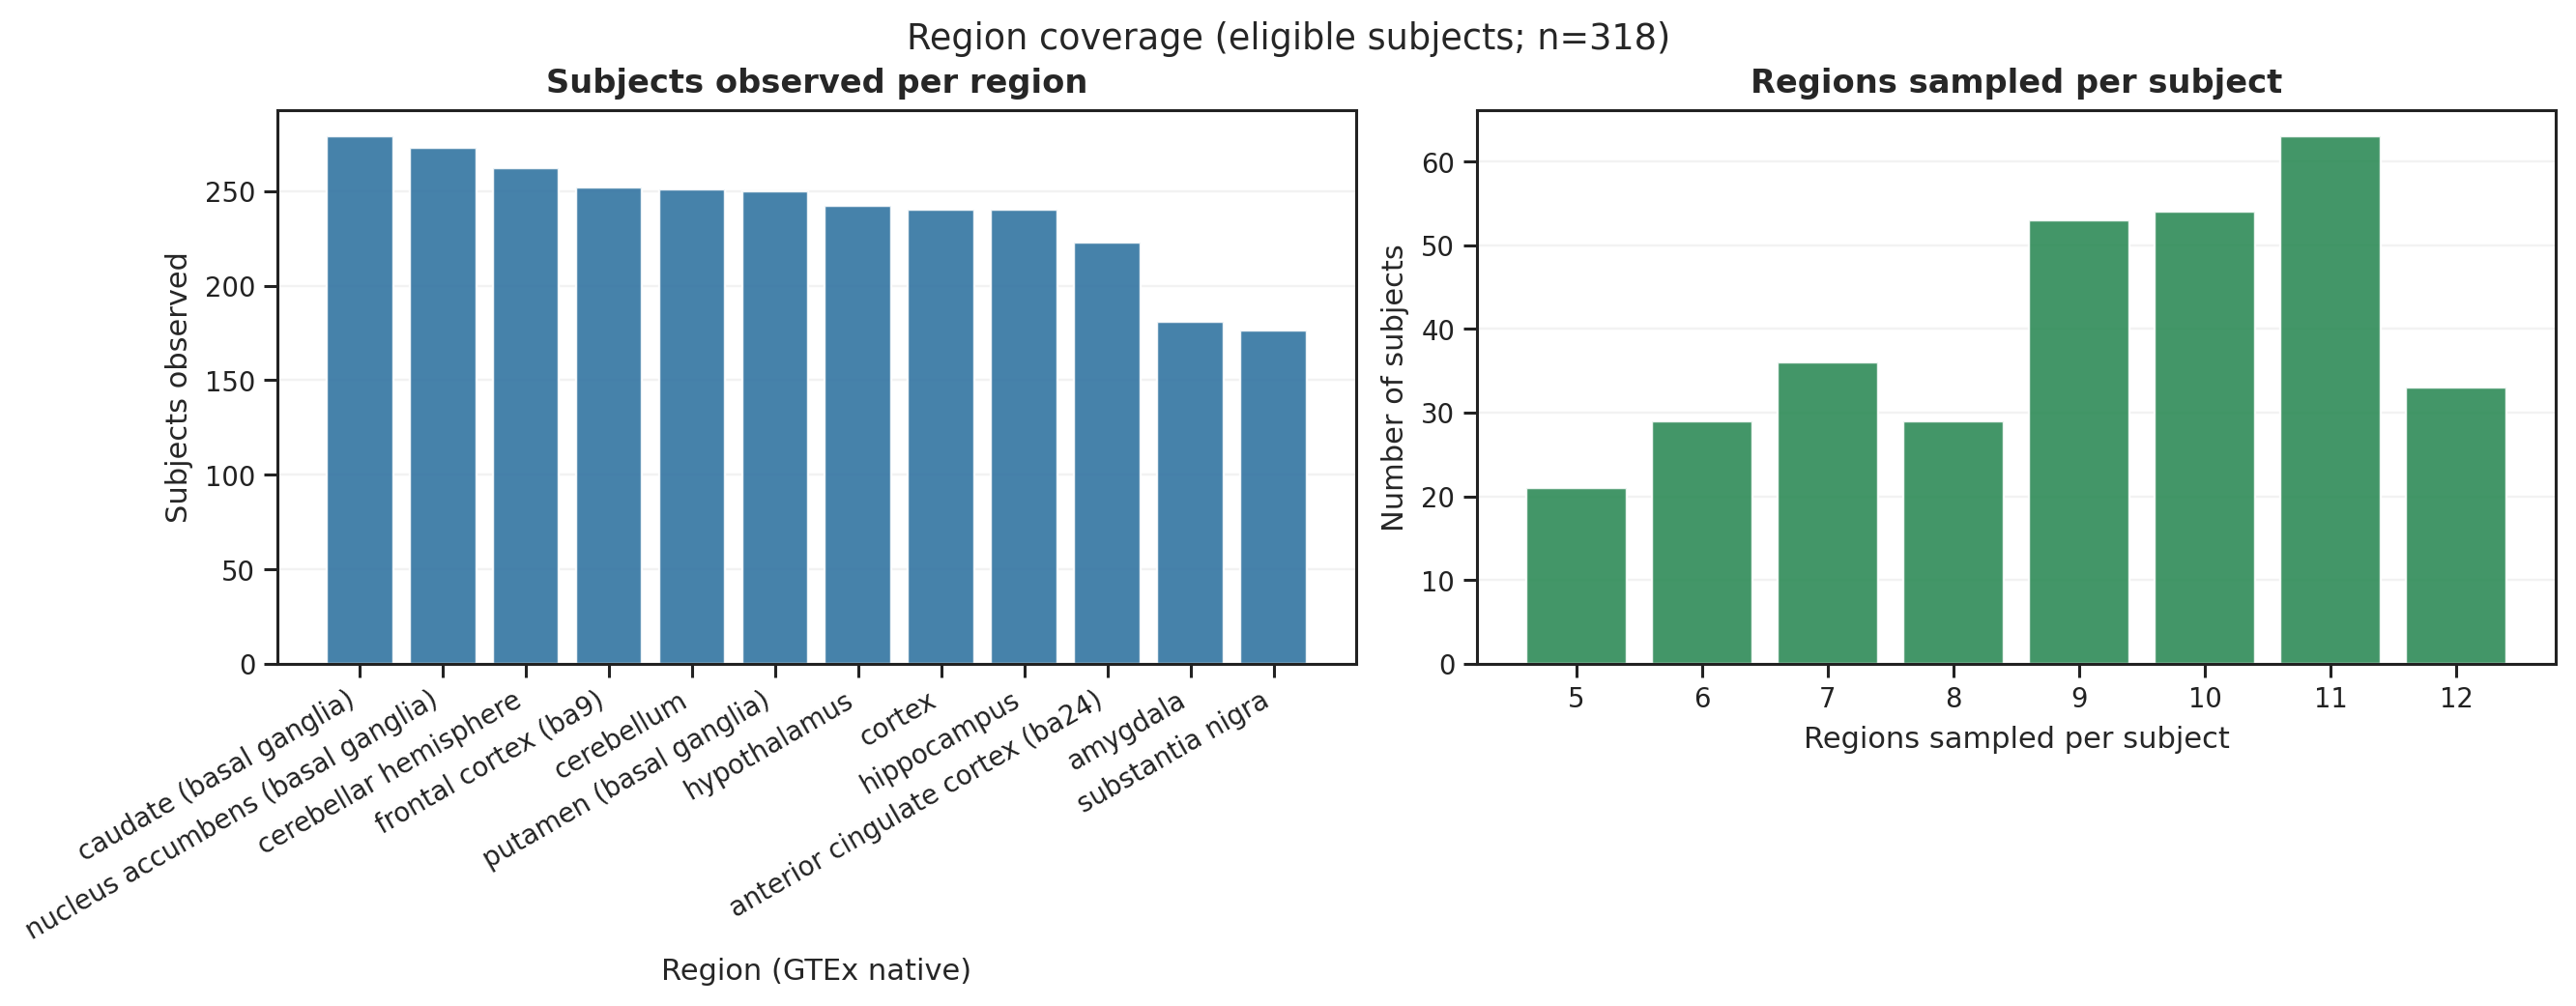

In [9]:
# Region coverage: subjects-per-region (left) and regions-per-subject (right)
fig, axes, cov_tables = plot_coverage_distributions(PREPOST, eligible_only=ELIGIBLE_ONLY)


In [10]:
CSV_PATH = "data/raw/gxp_samples.csv"
gxp_samples_df = pd.read_csv(CSV_PATH)


/tmp/ipykernel_625065/4168357976.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  gxp_samples_df = pd.read_csv(CSV_PATH)


Quick calls for writing gene lists

In [11]:
# from data.utils import (
#     build_and_write_hvg_gene_list,
#     build_and_write_tissue_deg_gene_list,
# )

# # GTEx HVGs: default tissue-discriminative
# out_path, ranked = build_and_write_hvg_gene_list(
#     samples_df=gxp_samples_df,
#     dataset="GTEx",
#     method="variance",
#     n_genes=100,
# )
# print("wrote", out_path)

# # GTEx HVGs: within-tissue / demeaned alternative
# out_path, ranked = build_and_write_hvg_gene_list(
#     samples_df=gxp_samples_df,
#     dataset="GTEx",
#     method="demeaned",
#     n_genes=100,
#     out_name=f"gtex_100hvg_demeaned.txt",
# )
# print("wrote", out_path)

# # GTEx tissue-enriched DEG panel: top 10 per tissue
# deg_path, deg_ranked = build_and_write_tissue_deg_gene_list(
#     samples_df=gxp_samples_df,
#     dataset="GTEx",
#     top_k_per_group=25,
#     out_name="gtex_25deg.txt",
# )
# print("wrote", deg_path)
# display(deg_ranked.head(24))


## 2) Pre/Post ComBat Diagnostics


### Pre/Post ComBat Expression Distributions

Histograms of all finite gene-expression values per dataset, before vs after ComBat: GTEx from `raw_cube` / `harm_cube`, AHBA from `ahba_raw` / `ahba_h`.

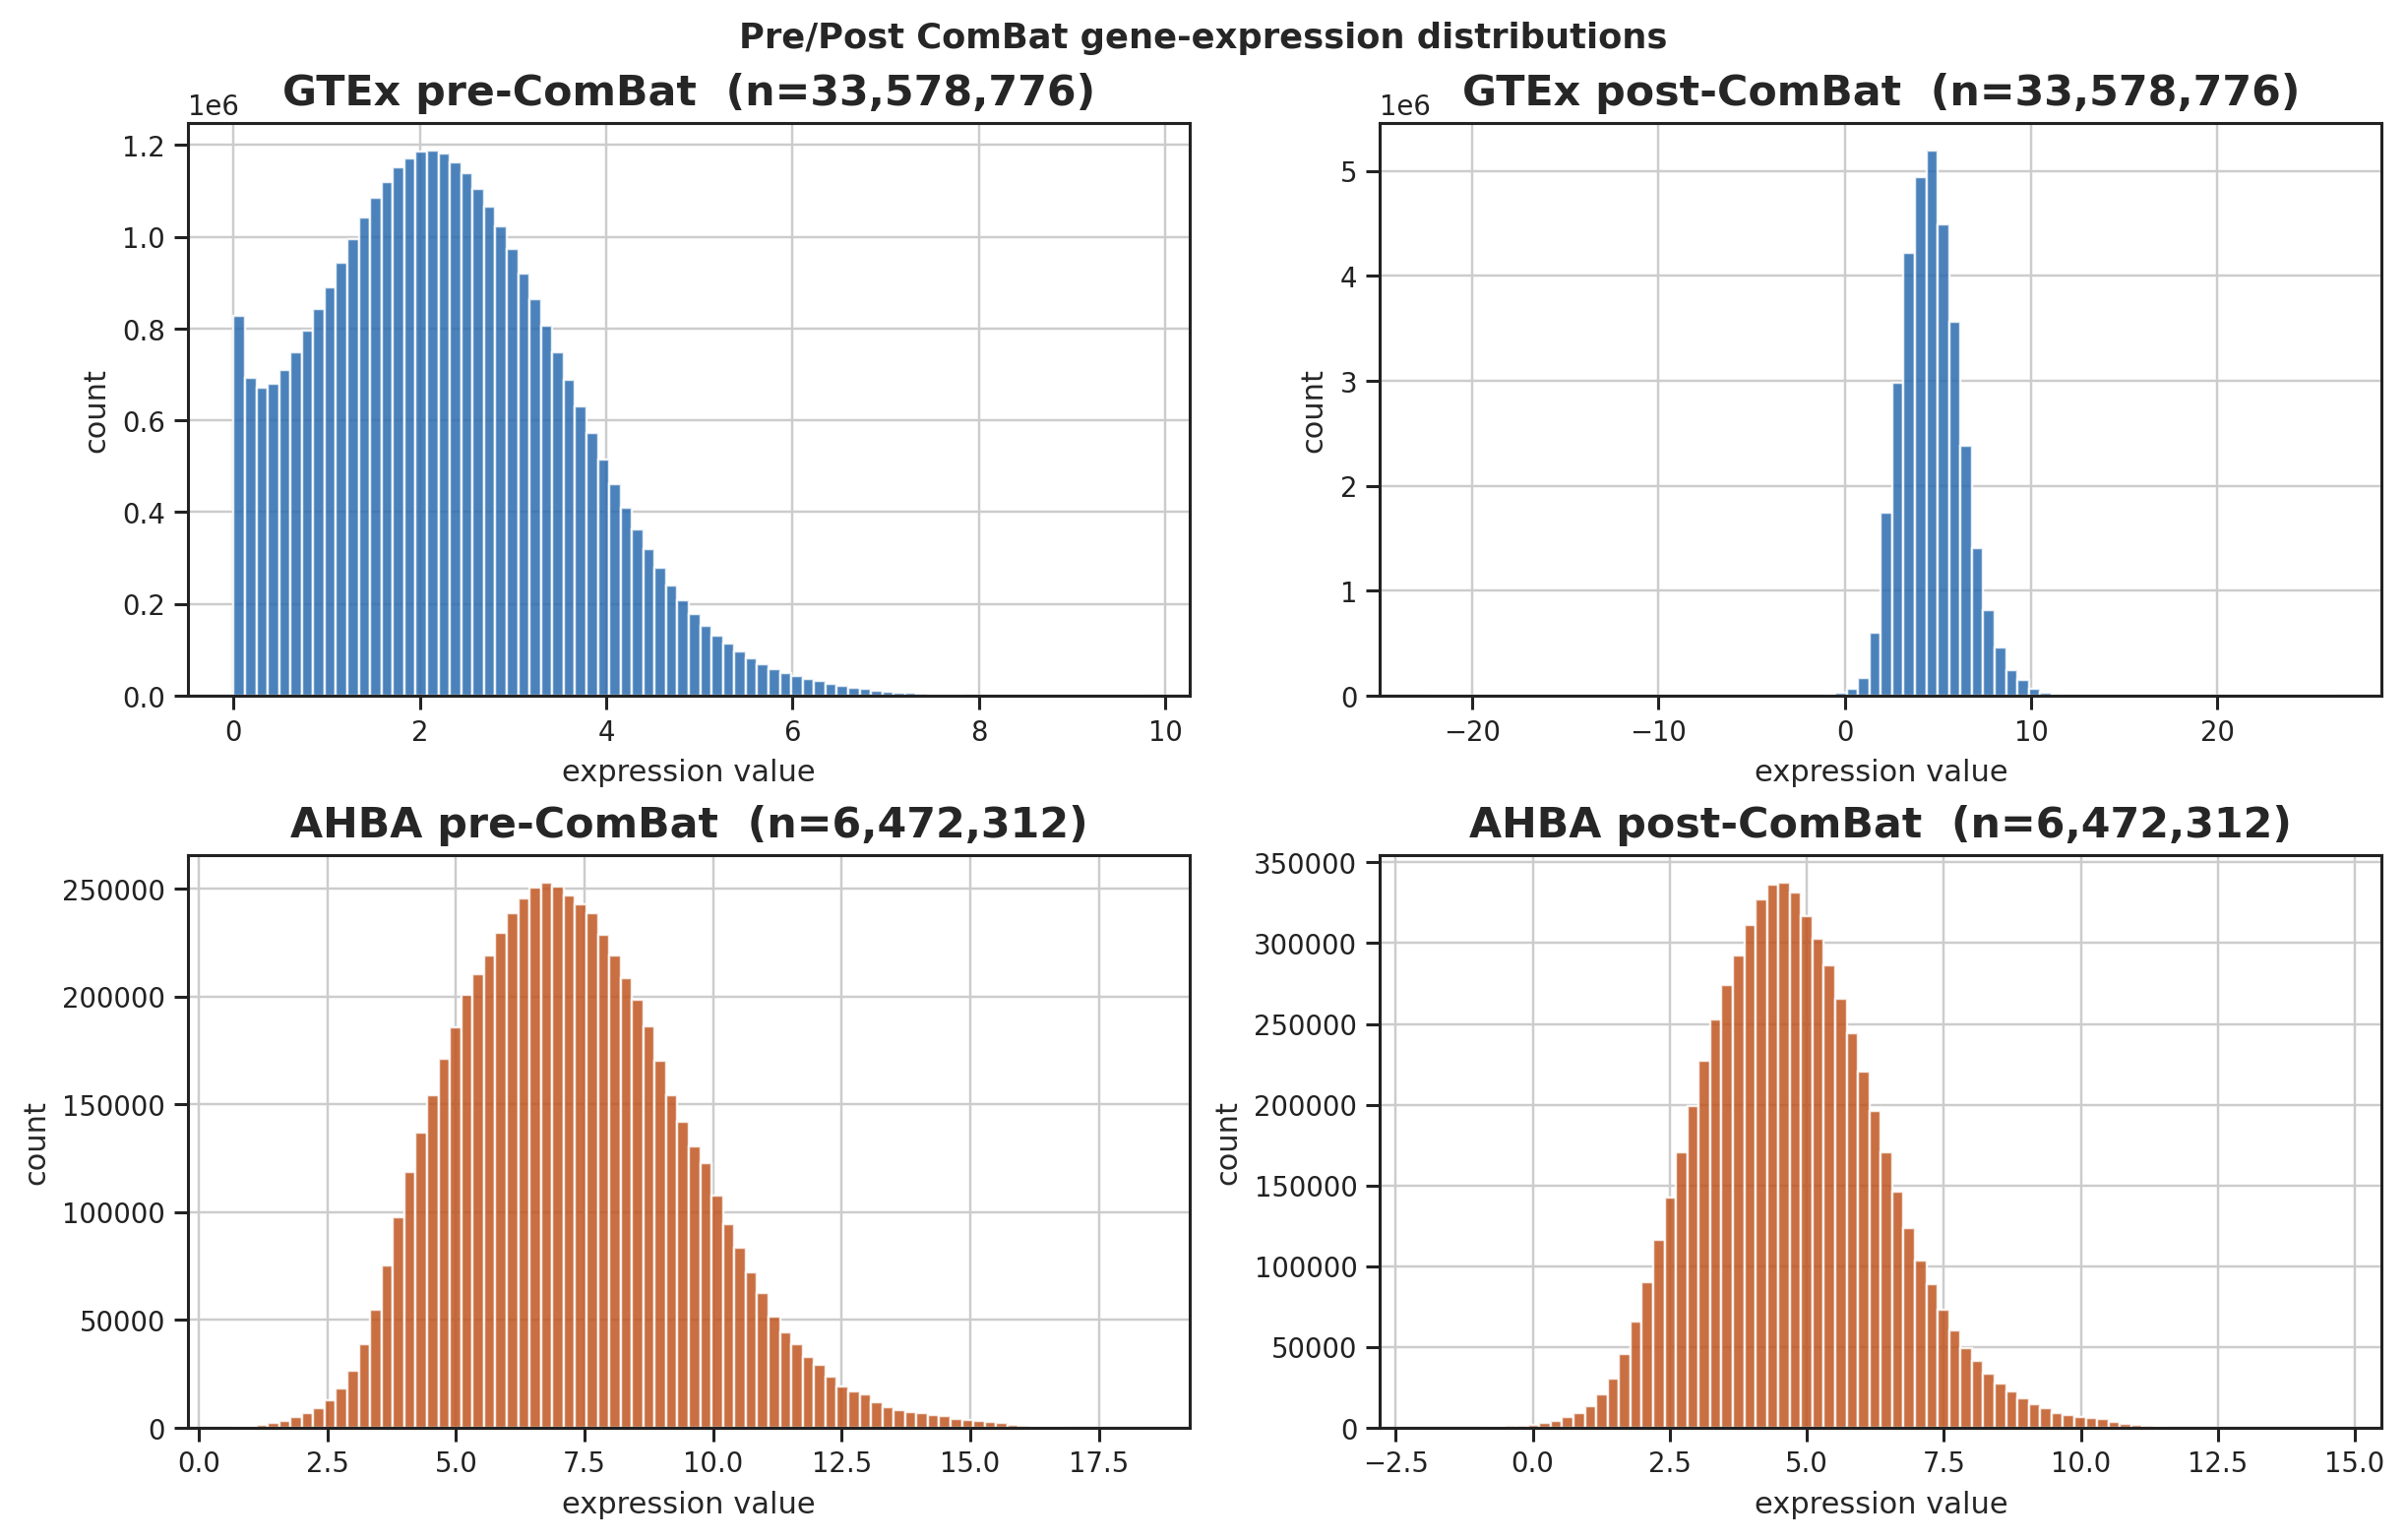

In [12]:
import numpy as np
import matplotlib.pyplot as plt

_genes = list(PREPOST['genes'])

def _finite_vals(a):
    a = np.asarray(a, dtype=np.float64).ravel()
    return a[np.isfinite(a)]

_panels = [
    ('GTEx pre-ComBat',  _finite_vals(PREPOST['raw_cube']),                 '#2b6cb0'),
    ('GTEx post-ComBat', _finite_vals(PREPOST['harm_cube']),                '#2b6cb0'),
    ('AHBA pre-ComBat',  _finite_vals(PREPOST['ahba_raw'][_genes].to_numpy()), '#c05621'),
    ('AHBA post-ComBat', _finite_vals(PREPOST['ahba_h'][_genes].to_numpy()),   '#c05621'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
for ax, (title, vals, color) in zip(axes.ravel(), _panels):
    ax.hist(vals, bins=80, color=color, alpha=0.85)
    ax.set_title(f'{title}  (n={vals.size:,})')
    ax.set_xlabel('expression value')
    ax.set_ylabel('count')
fig.suptitle('Pre/Post ComBat gene-expression distributions', fontweight='bold')
plt.show()

In [13]:
# gene_mode: 'allgenes' | 'custom'
# Use gene_mode='custom' with eval_gene_list_path for named panels such as 'gtex_100hvg'.
GENE_MODE = 'custom'
EVAL_GENE_LIST_PATH = 'gtex_100hvg'
CUSTOM_GENE_LIST = None

atlas_cmp_mean = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    summary_stat='mean',
)
atlas_cmp = prepare_atlas_median_comparison(
    PREPOST,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    summary_stat='median',
)
print('atlas parcels:', len(atlas_cmp['parcel_labels']))
print('genes in panel:', len(atlas_cmp['genes']))


atlas parcels: 12
genes in panel: 94


### Mean Matrix Comparison


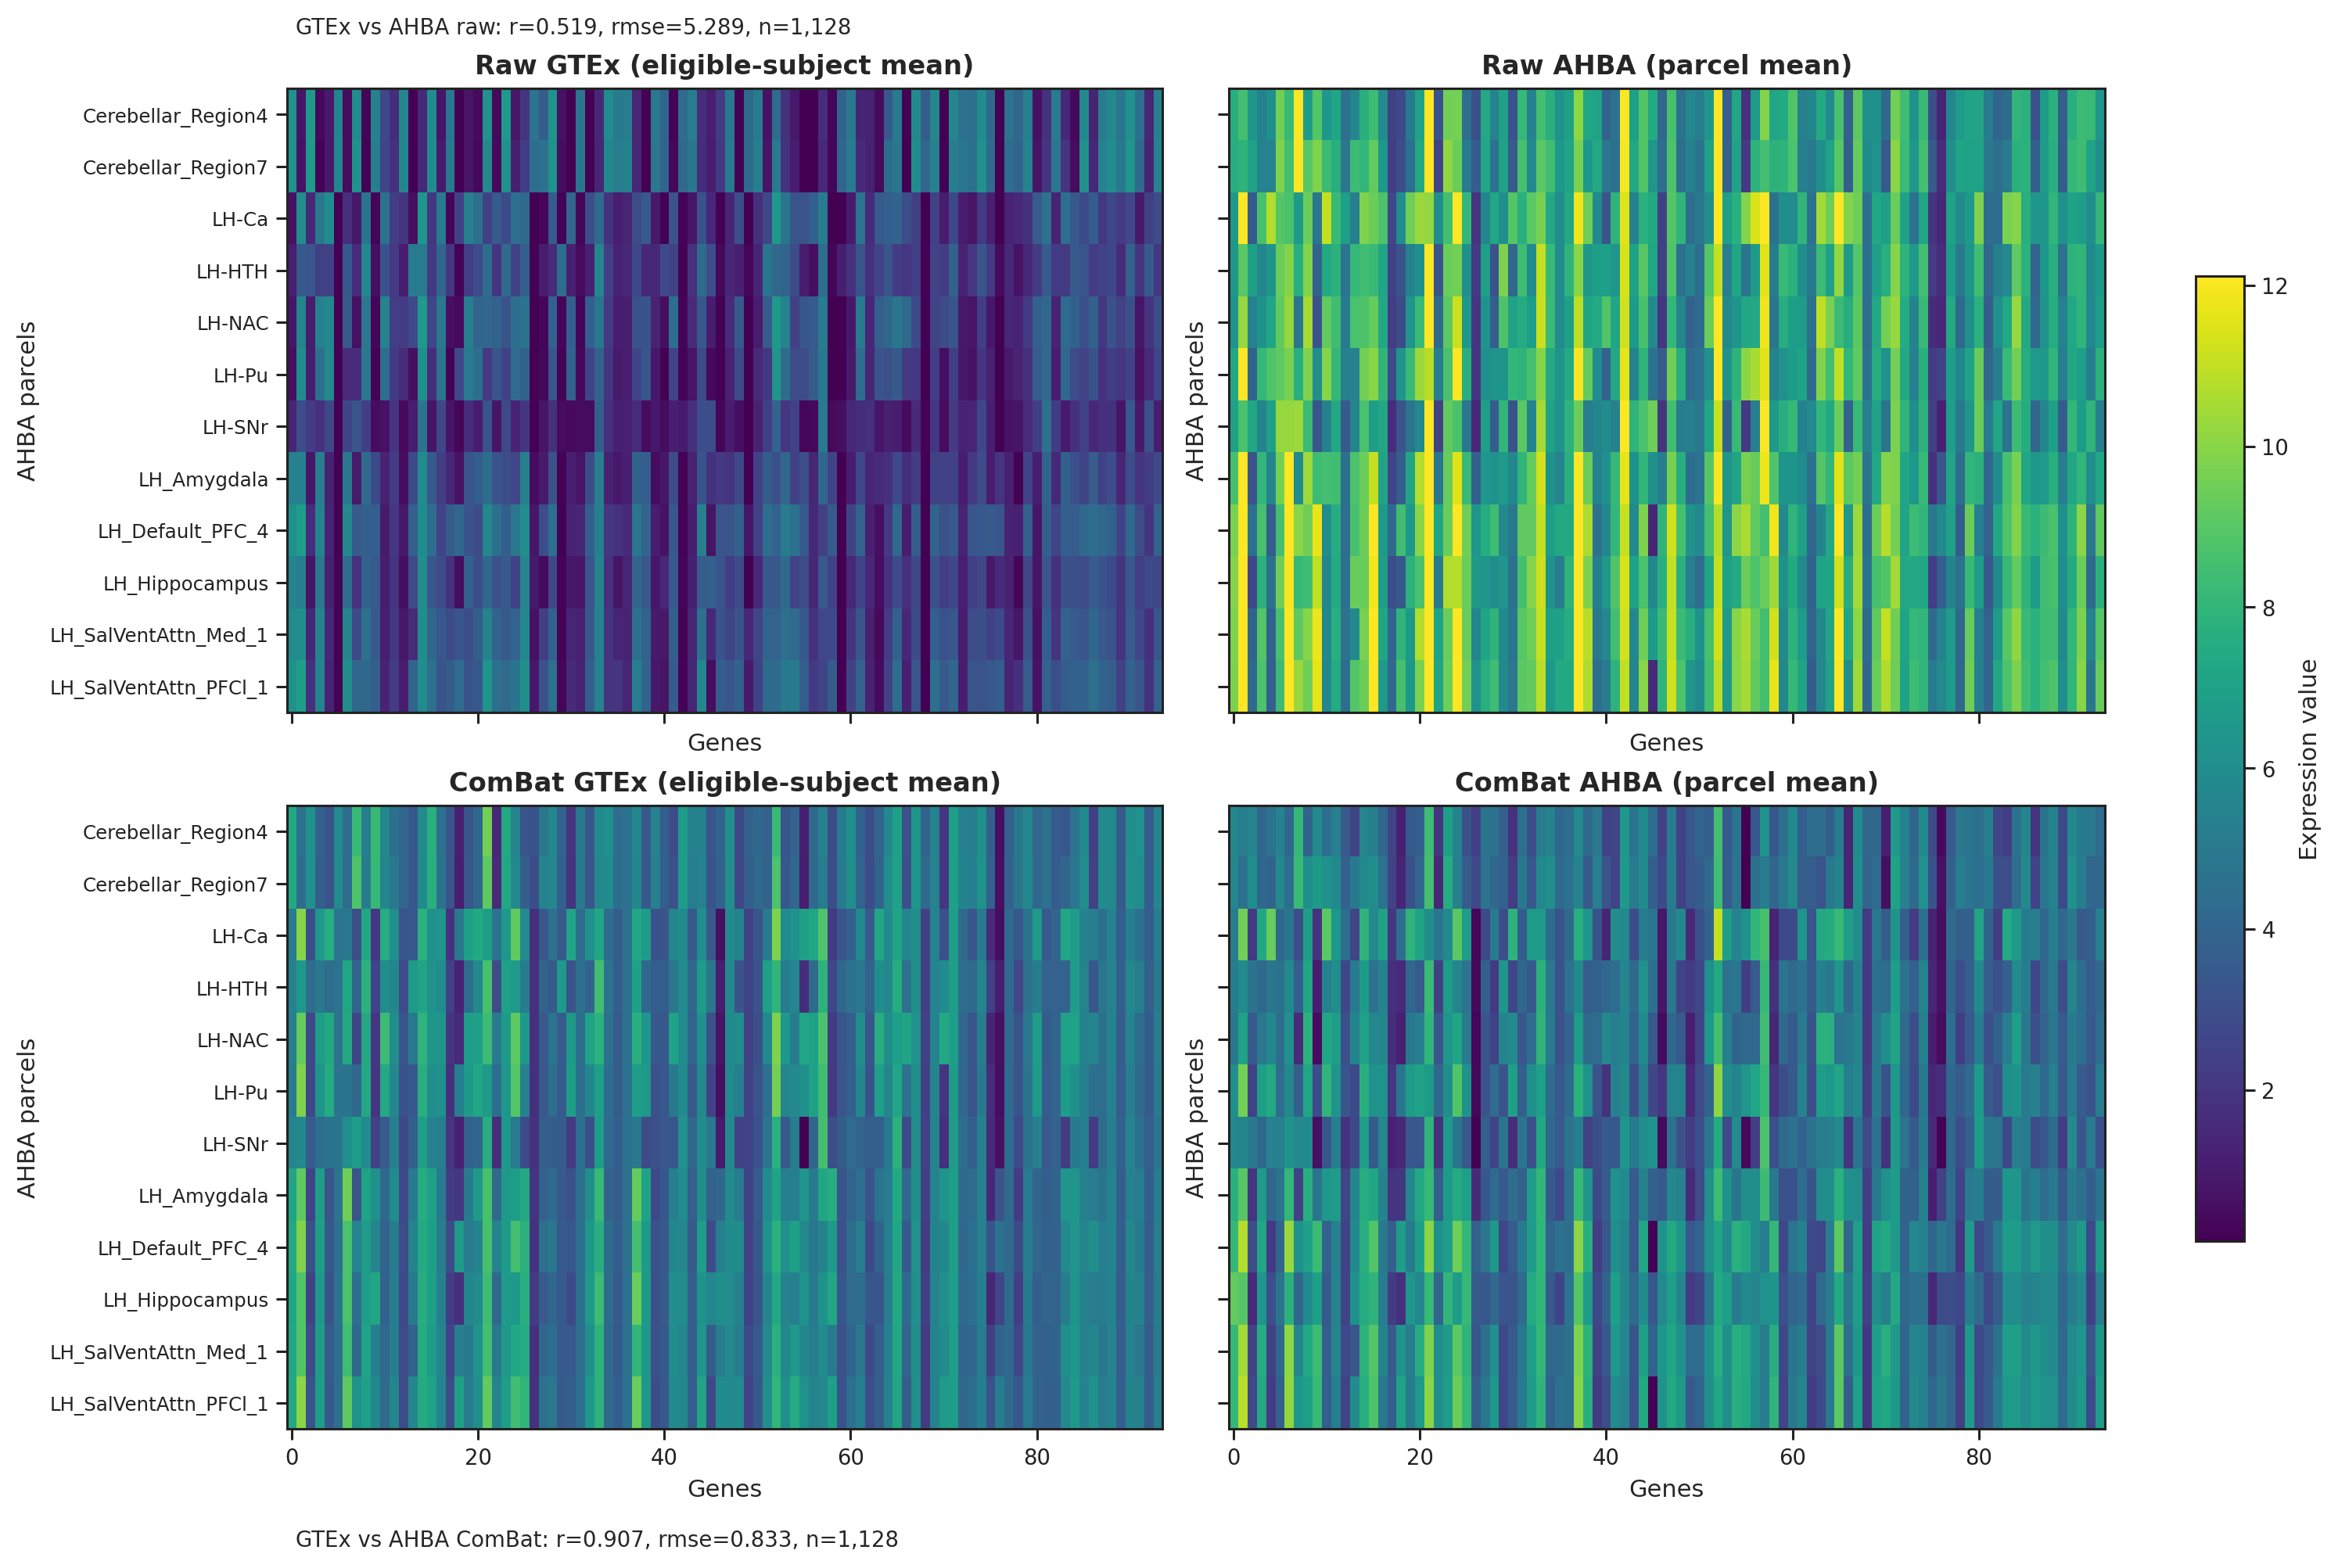

In [14]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp_mean, label_stride=1)


### Median Matrix Comparison


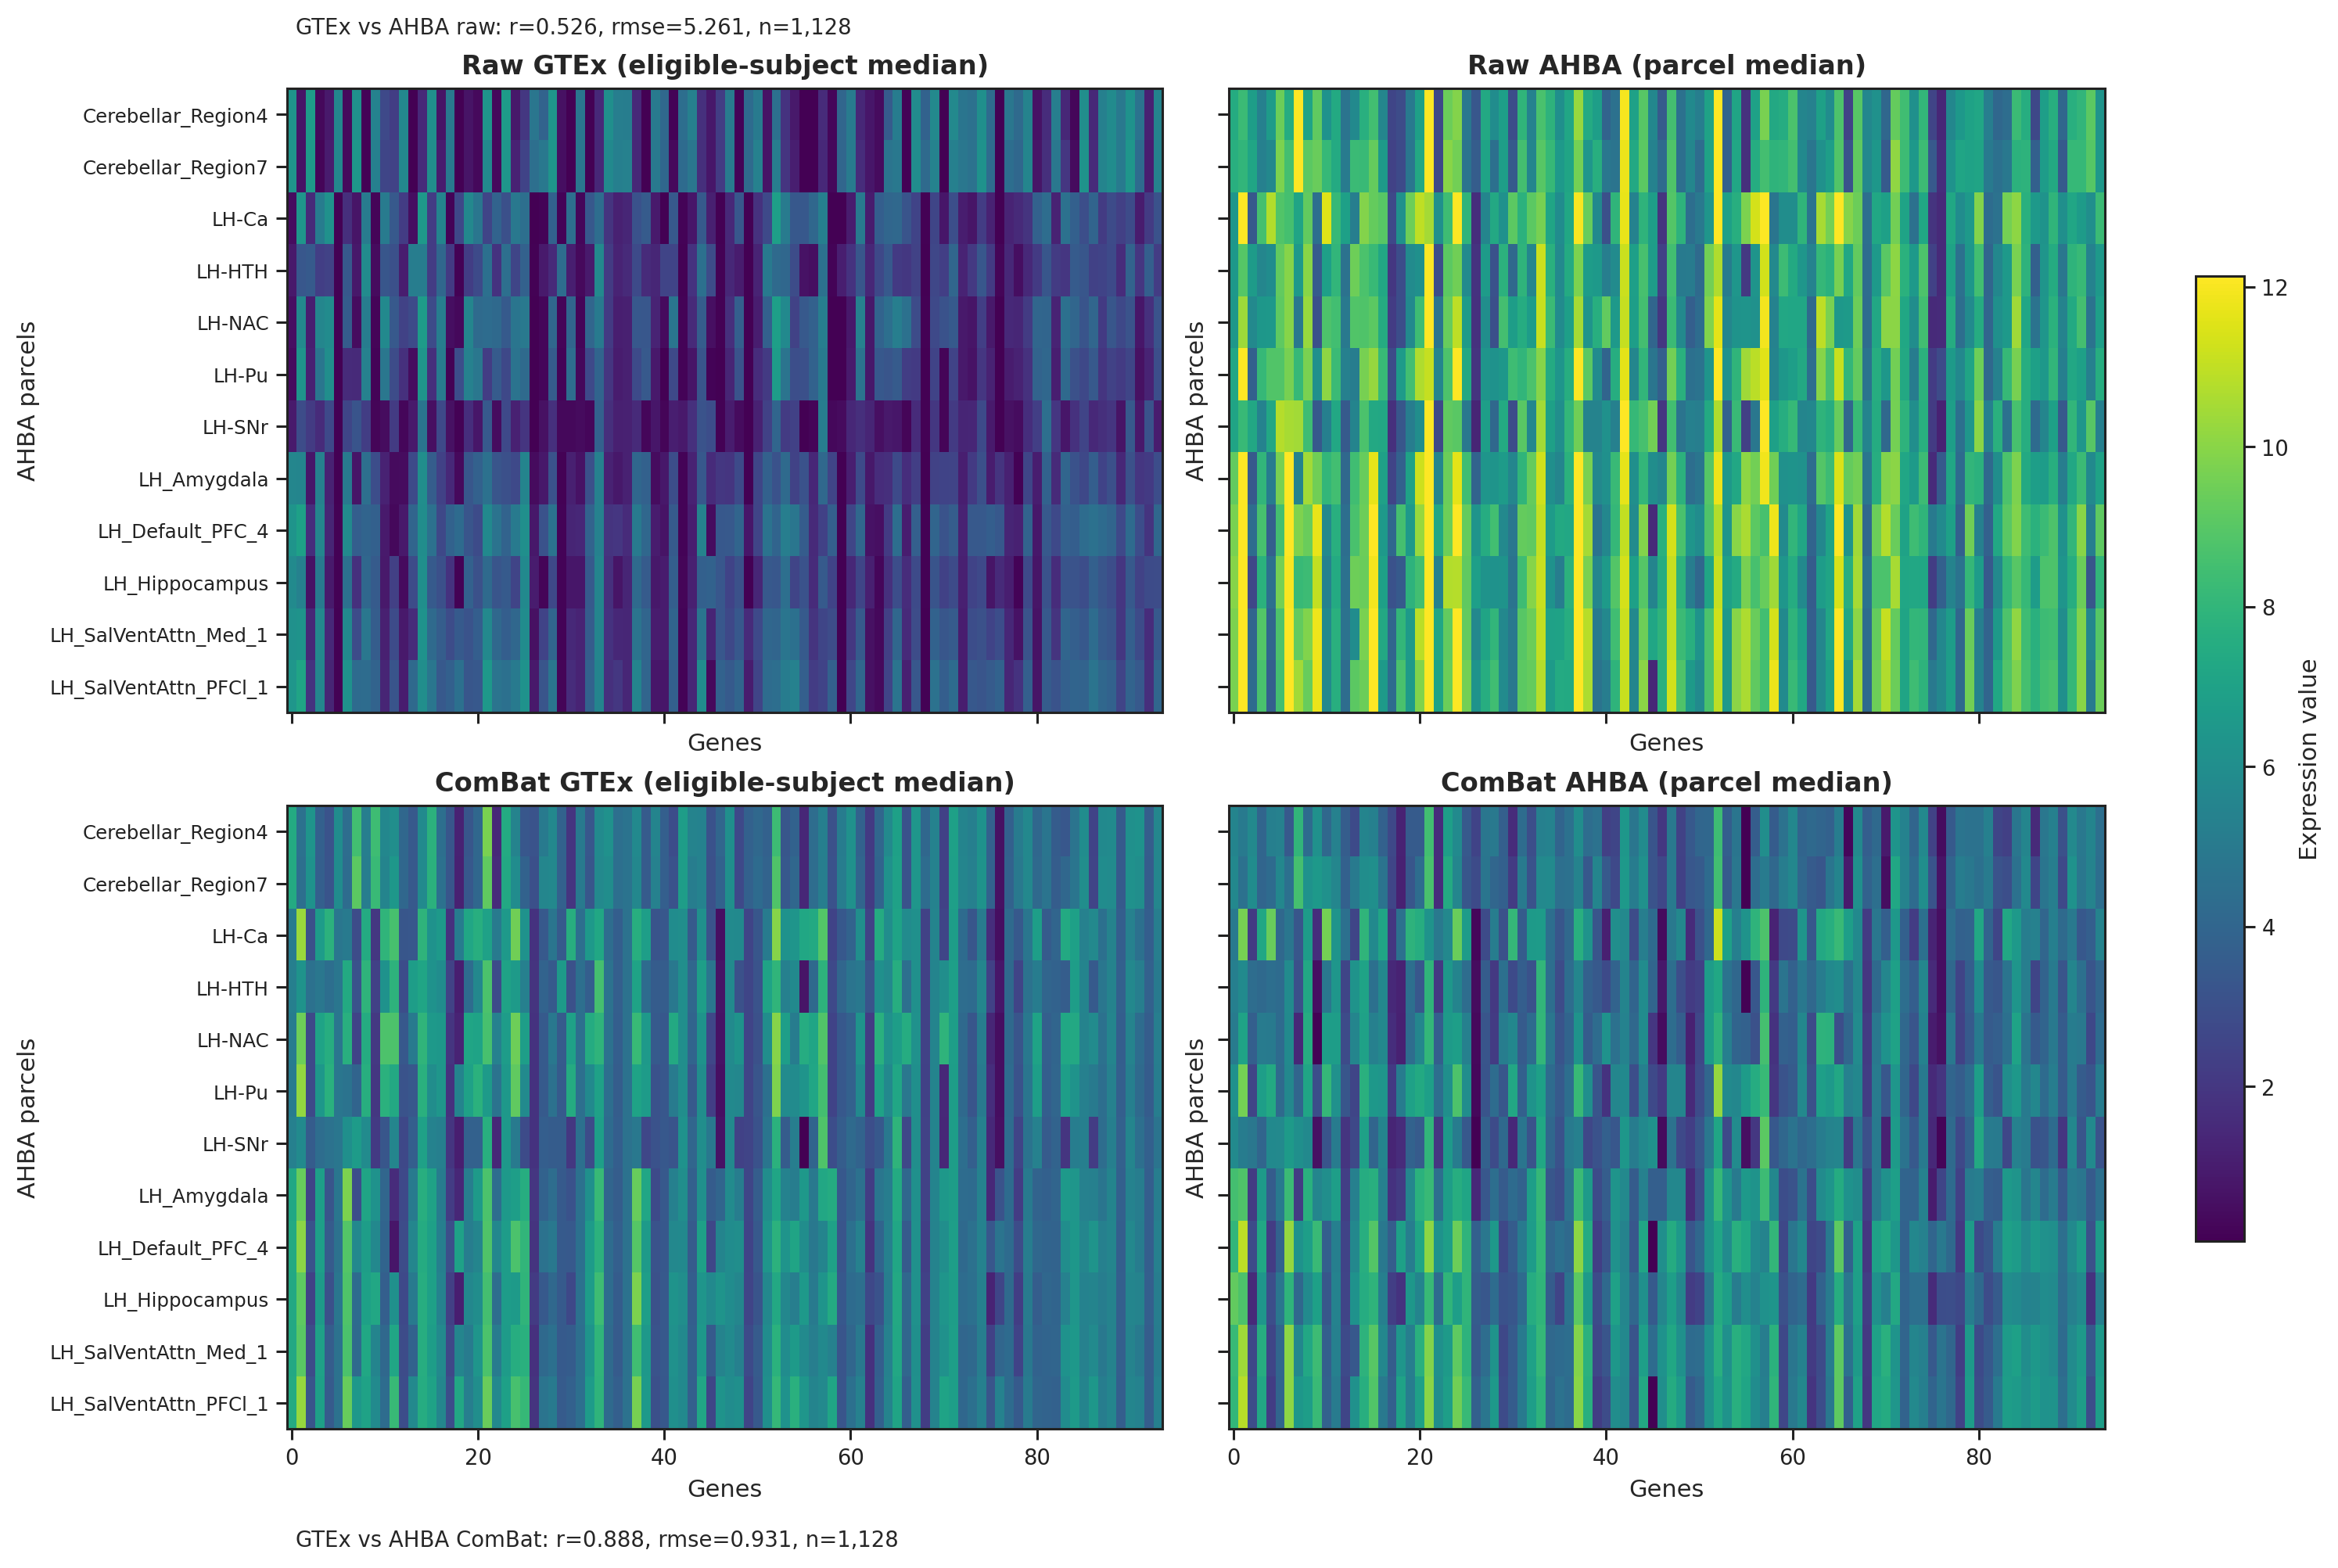

In [15]:
fig, axes = plot_atlas_median_comparison_heatmaps(atlas_cmp, label_stride=1)


### Single Subjects Pre-Post Combat Matrix Comparison


subject: GTEX-1117F
subject: GTEX-111FC
subject: GTEX-11EMC


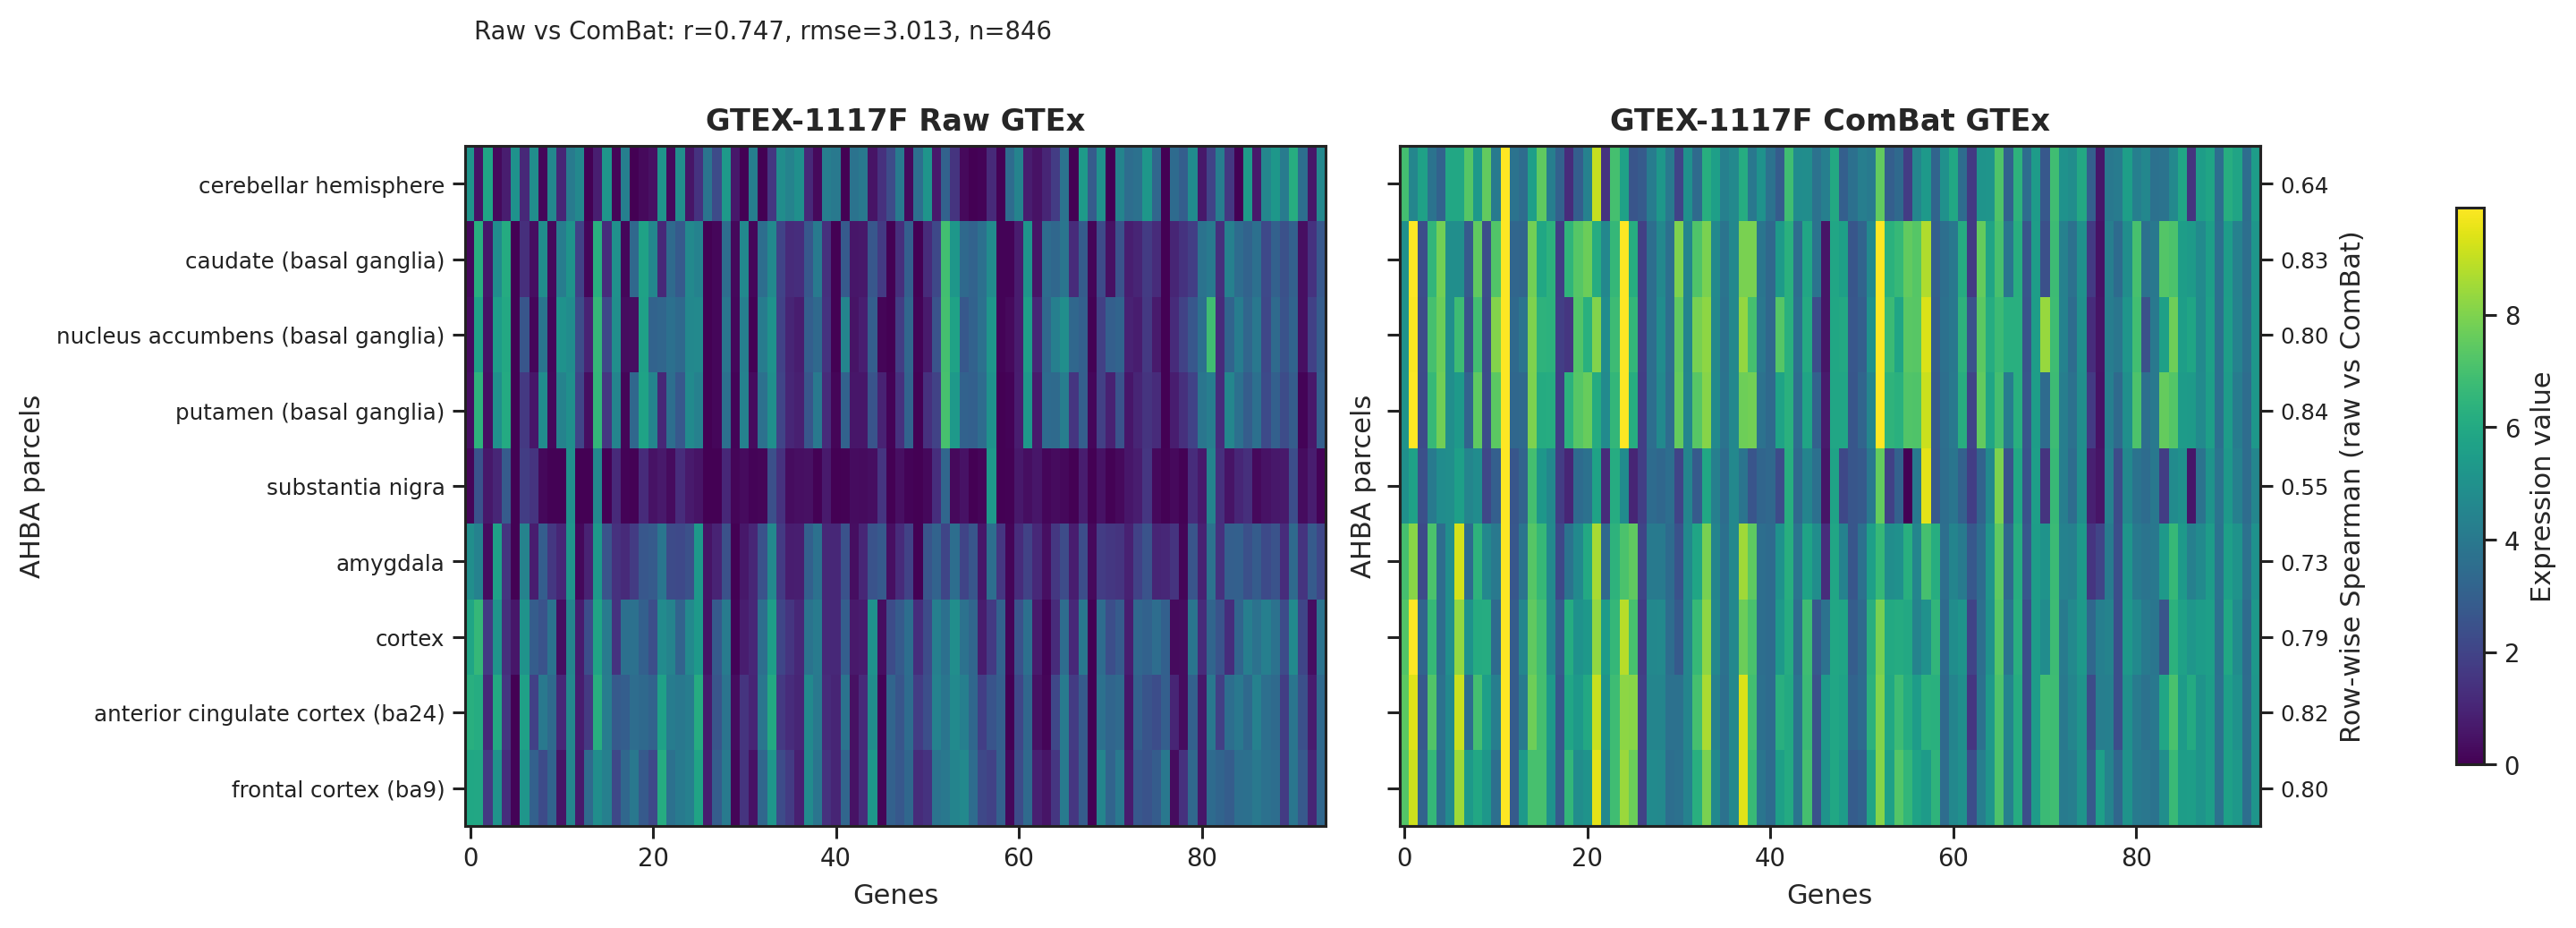

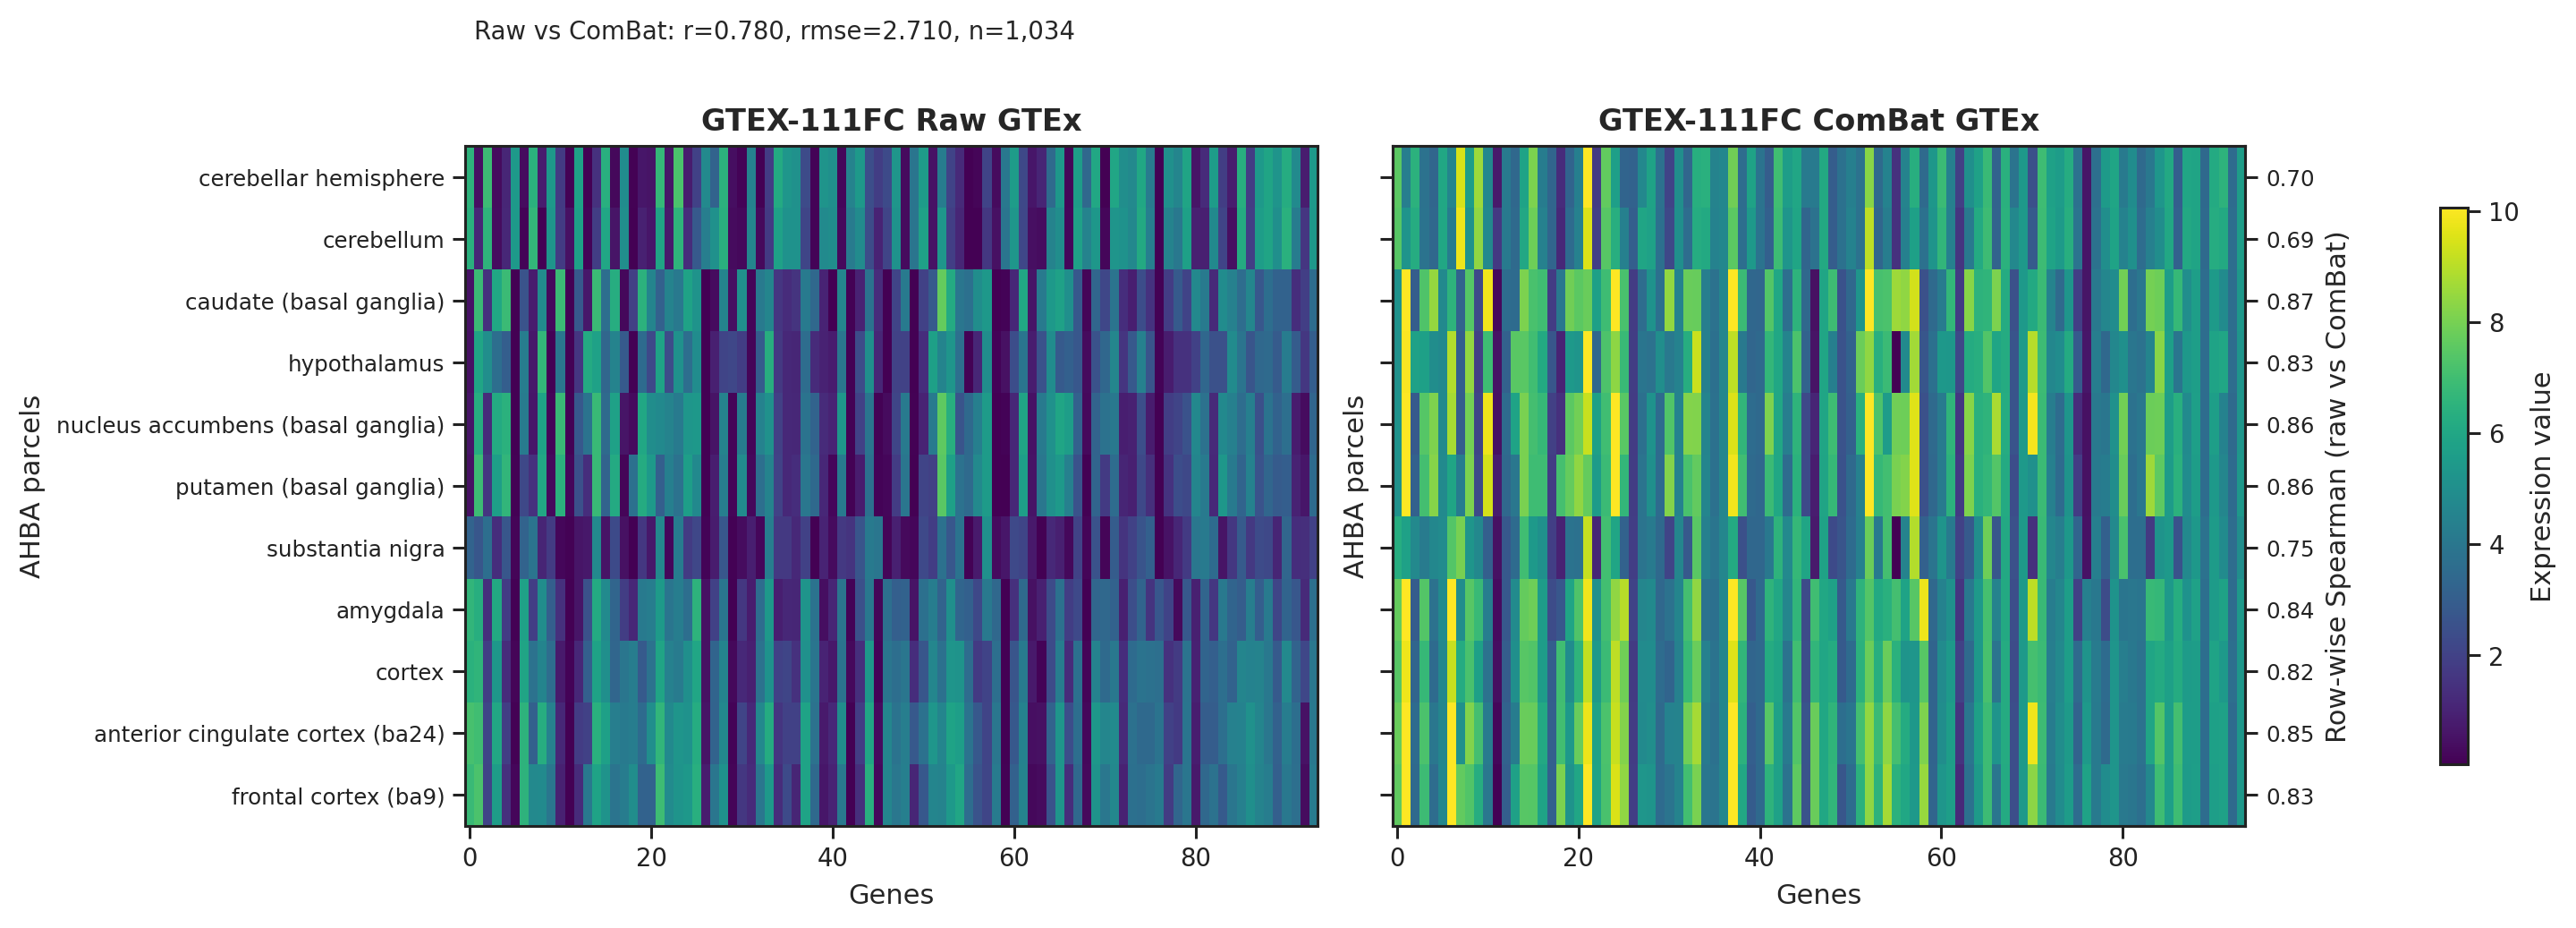

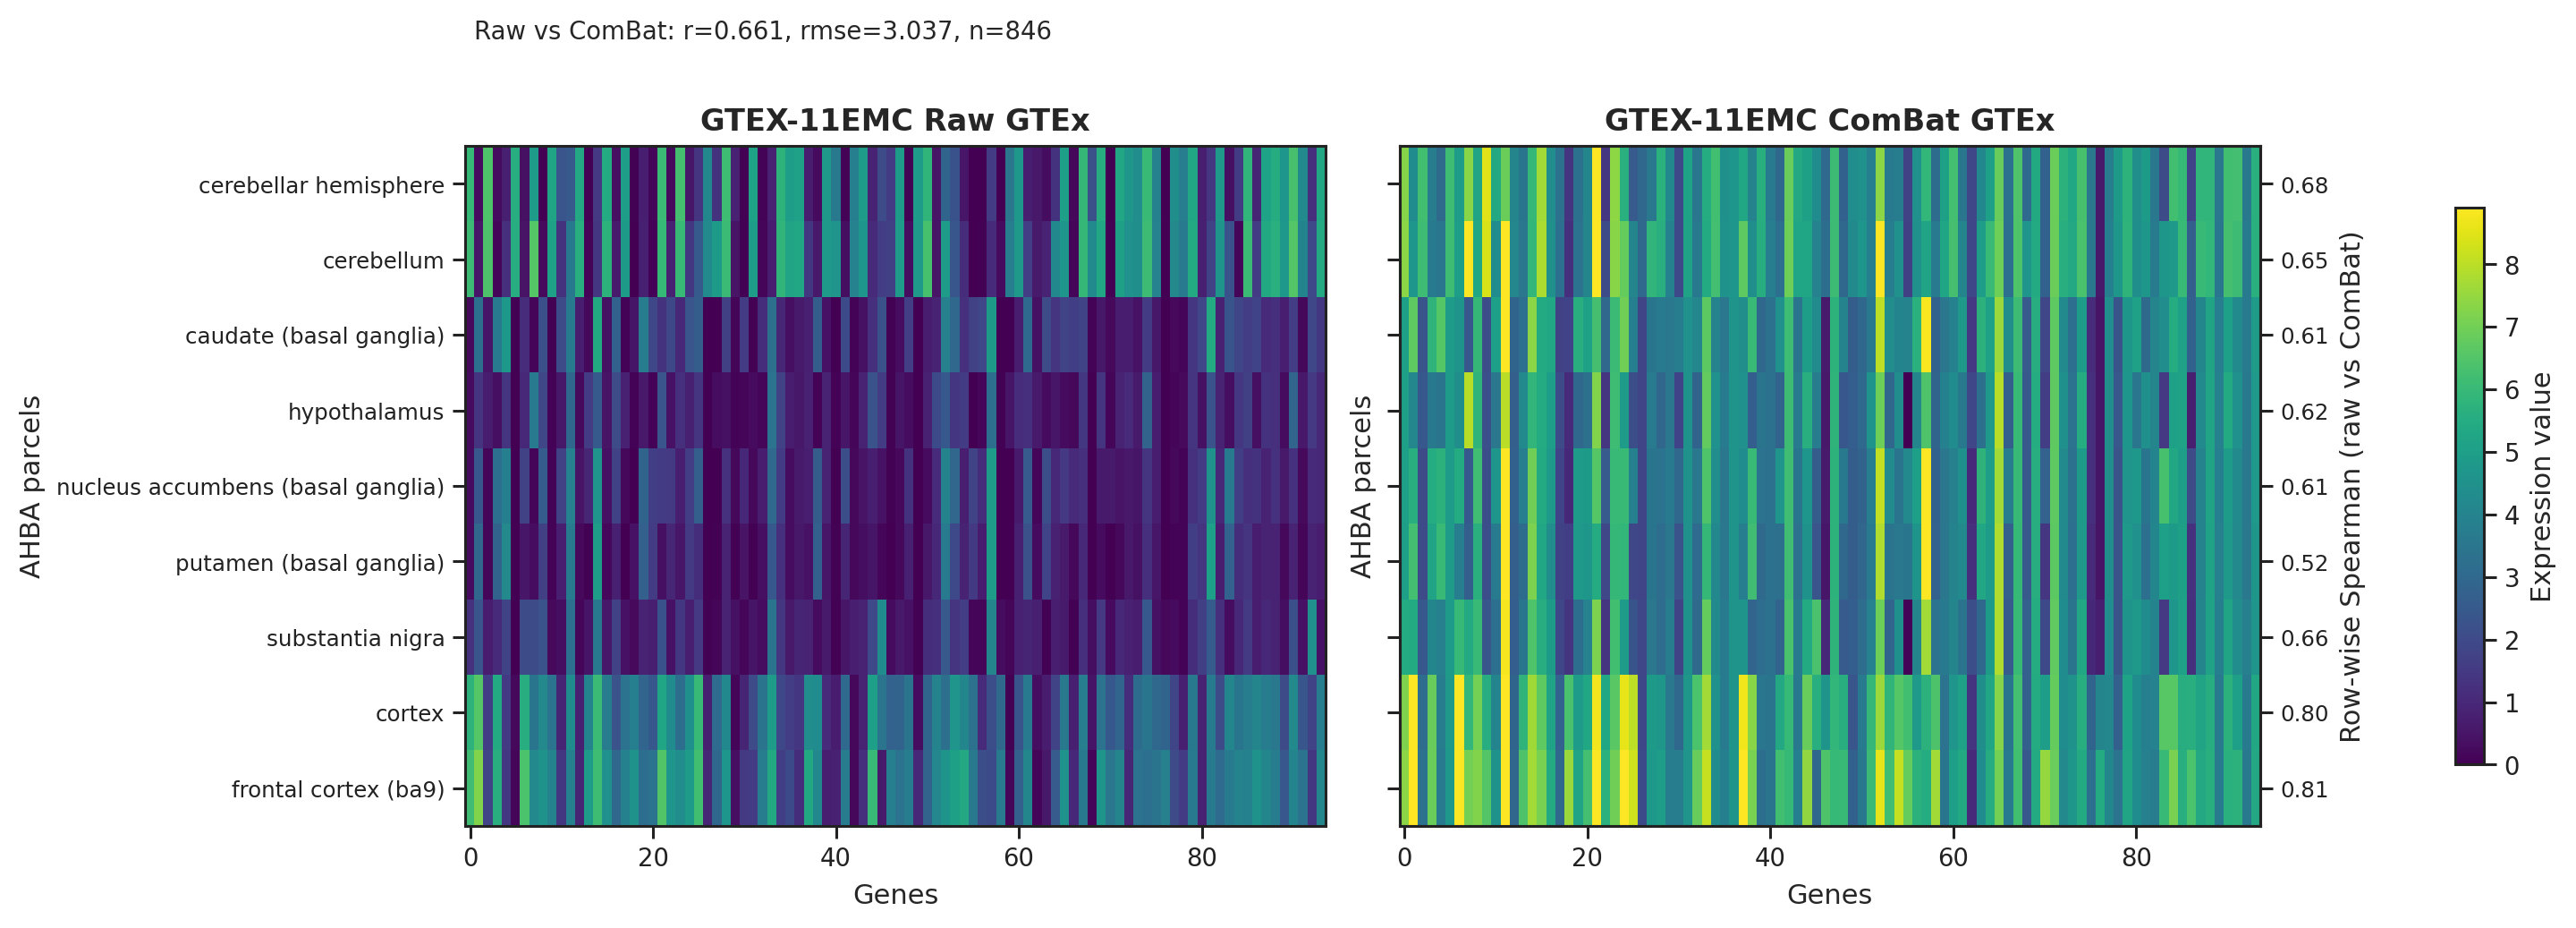

In [16]:
# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][0]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)

# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][1]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)

# Single-subject pre/post (GTEx only)
SUBJECT_ID = PREPOST['subjects'][10]
fig, axes = plot_subject_prepost_heatmaps(
    PREPOST,
    subject_id=SUBJECT_ID,
    gene_mode=GENE_MODE,
    custom_gene_list=CUSTOM_GENE_LIST,
    eval_gene_list_path=EVAL_GENE_LIST_PATH,
    observed_only=True,
    label_stride=1,
)
print('subject:', SUBJECT_ID)


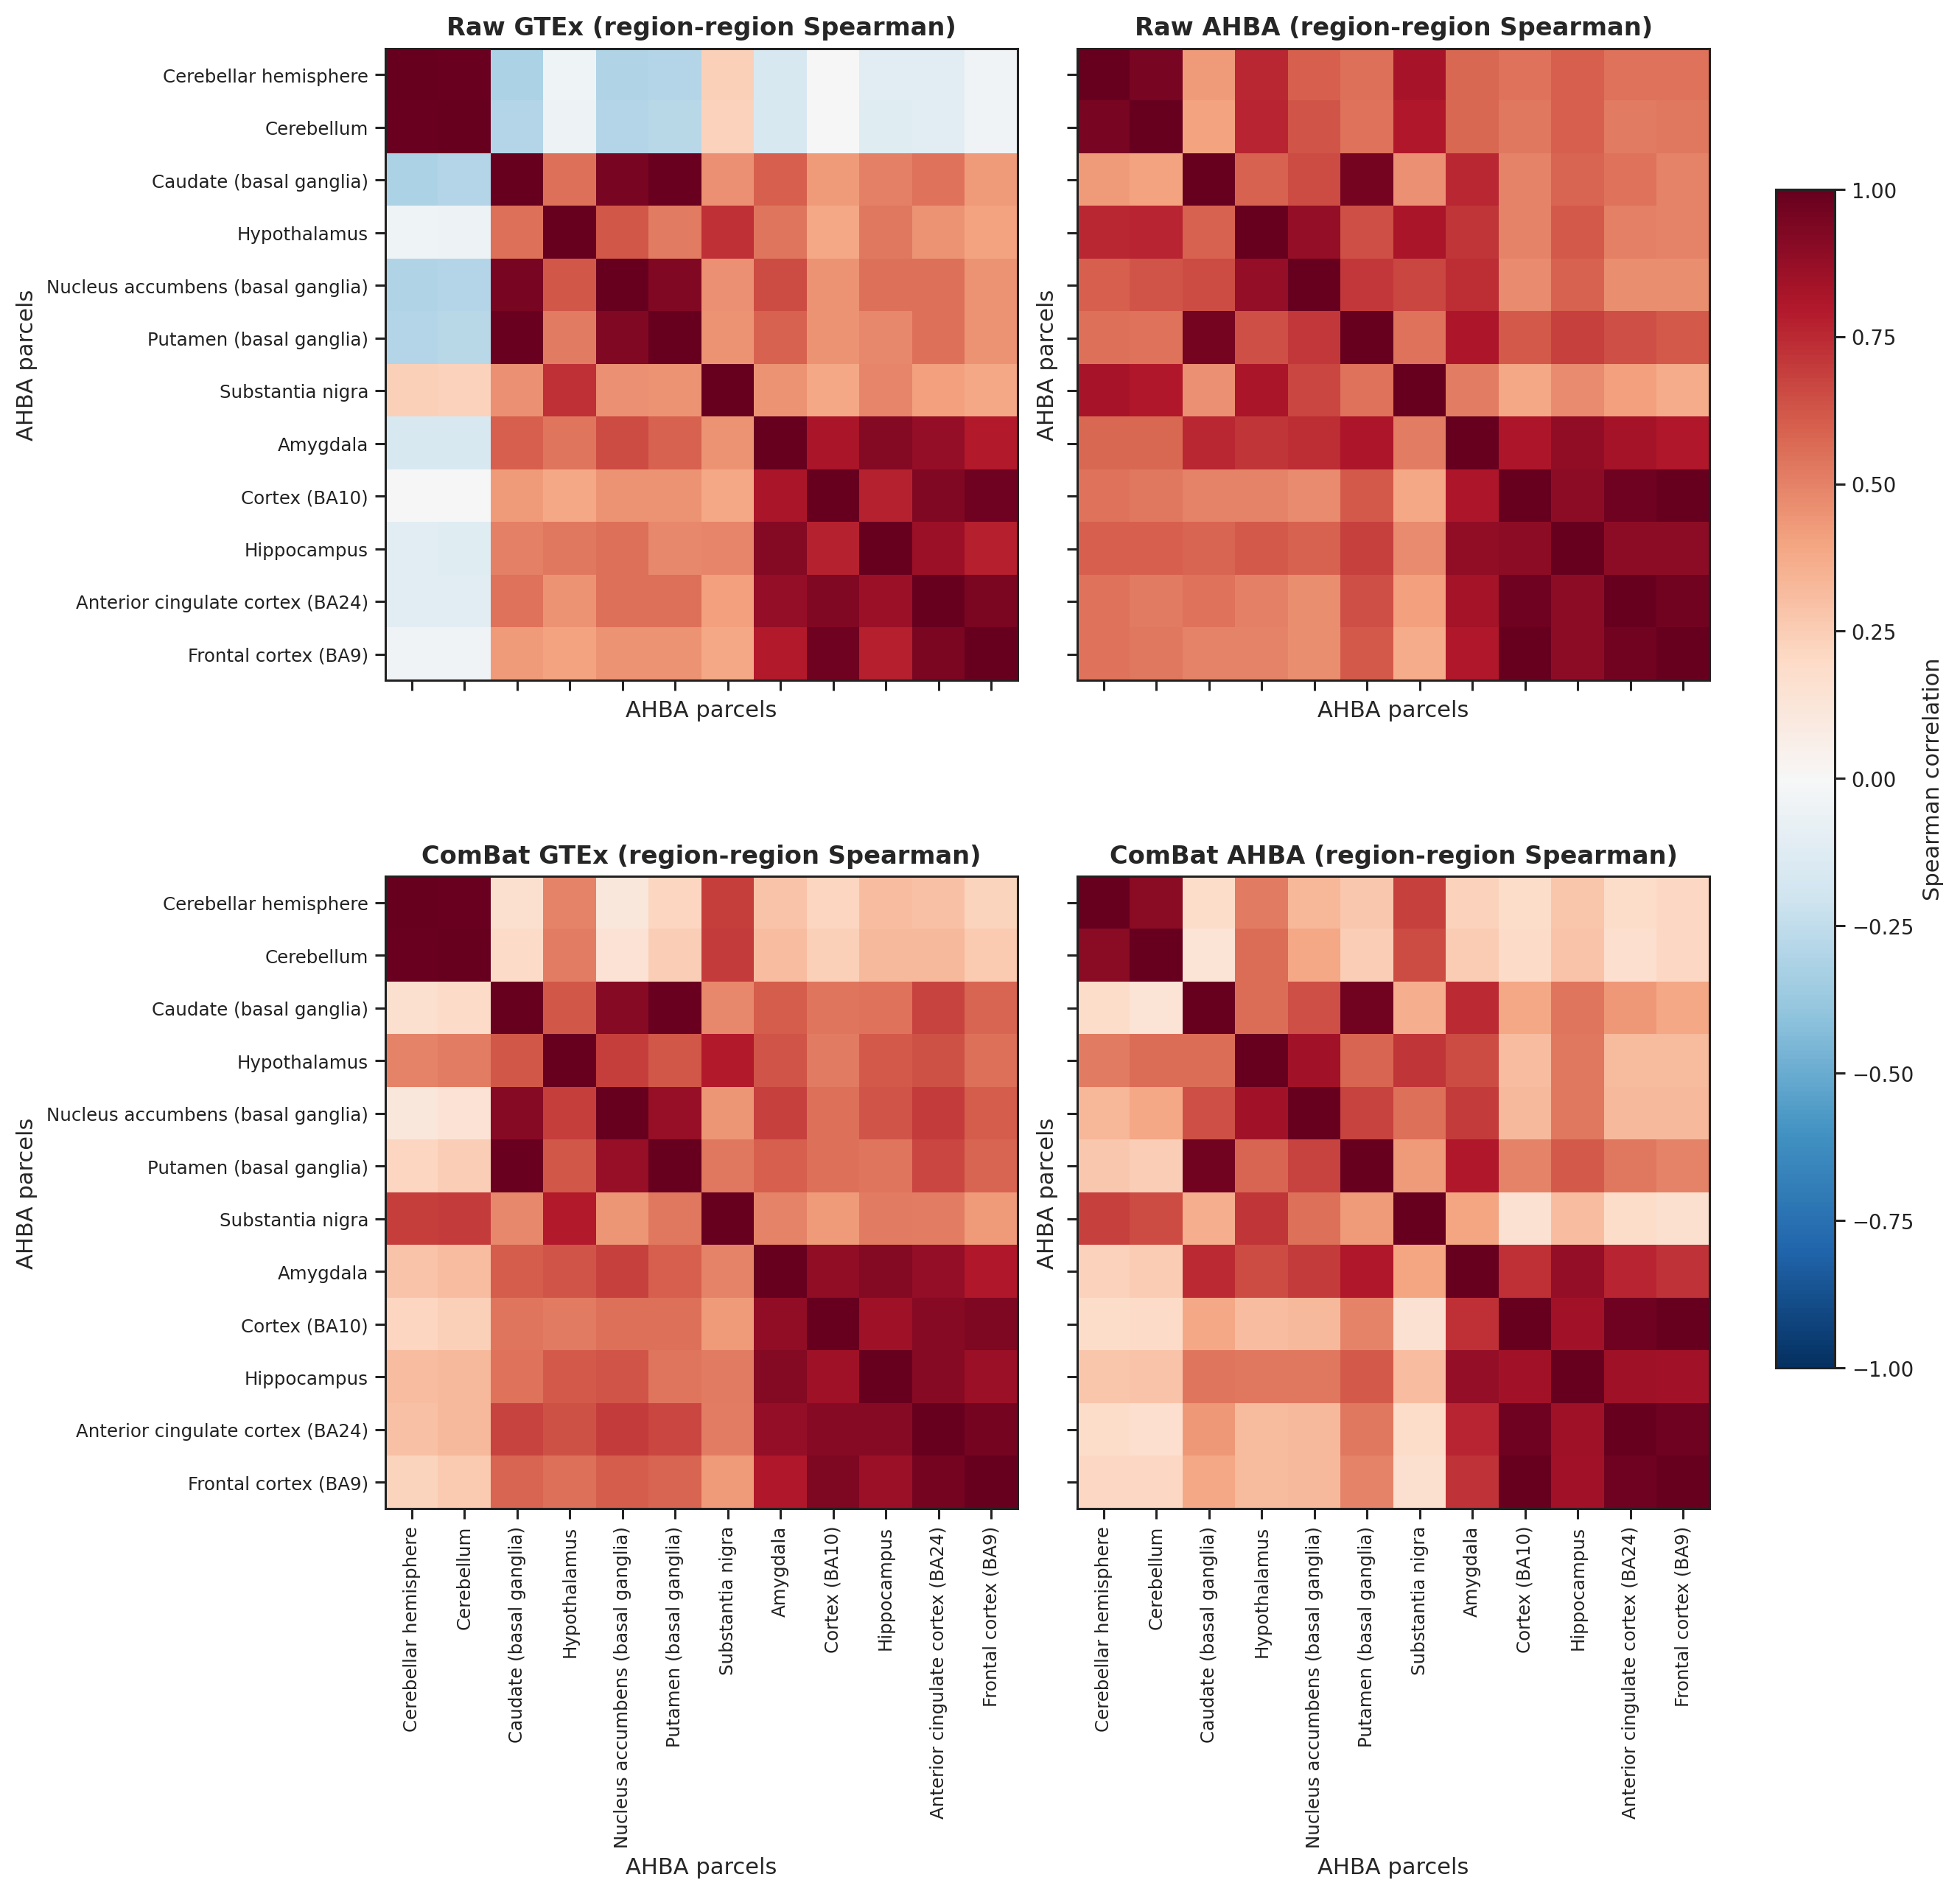

In [17]:
fig, axes = plot_region_region_spearman_heatmaps(atlas_cmp)


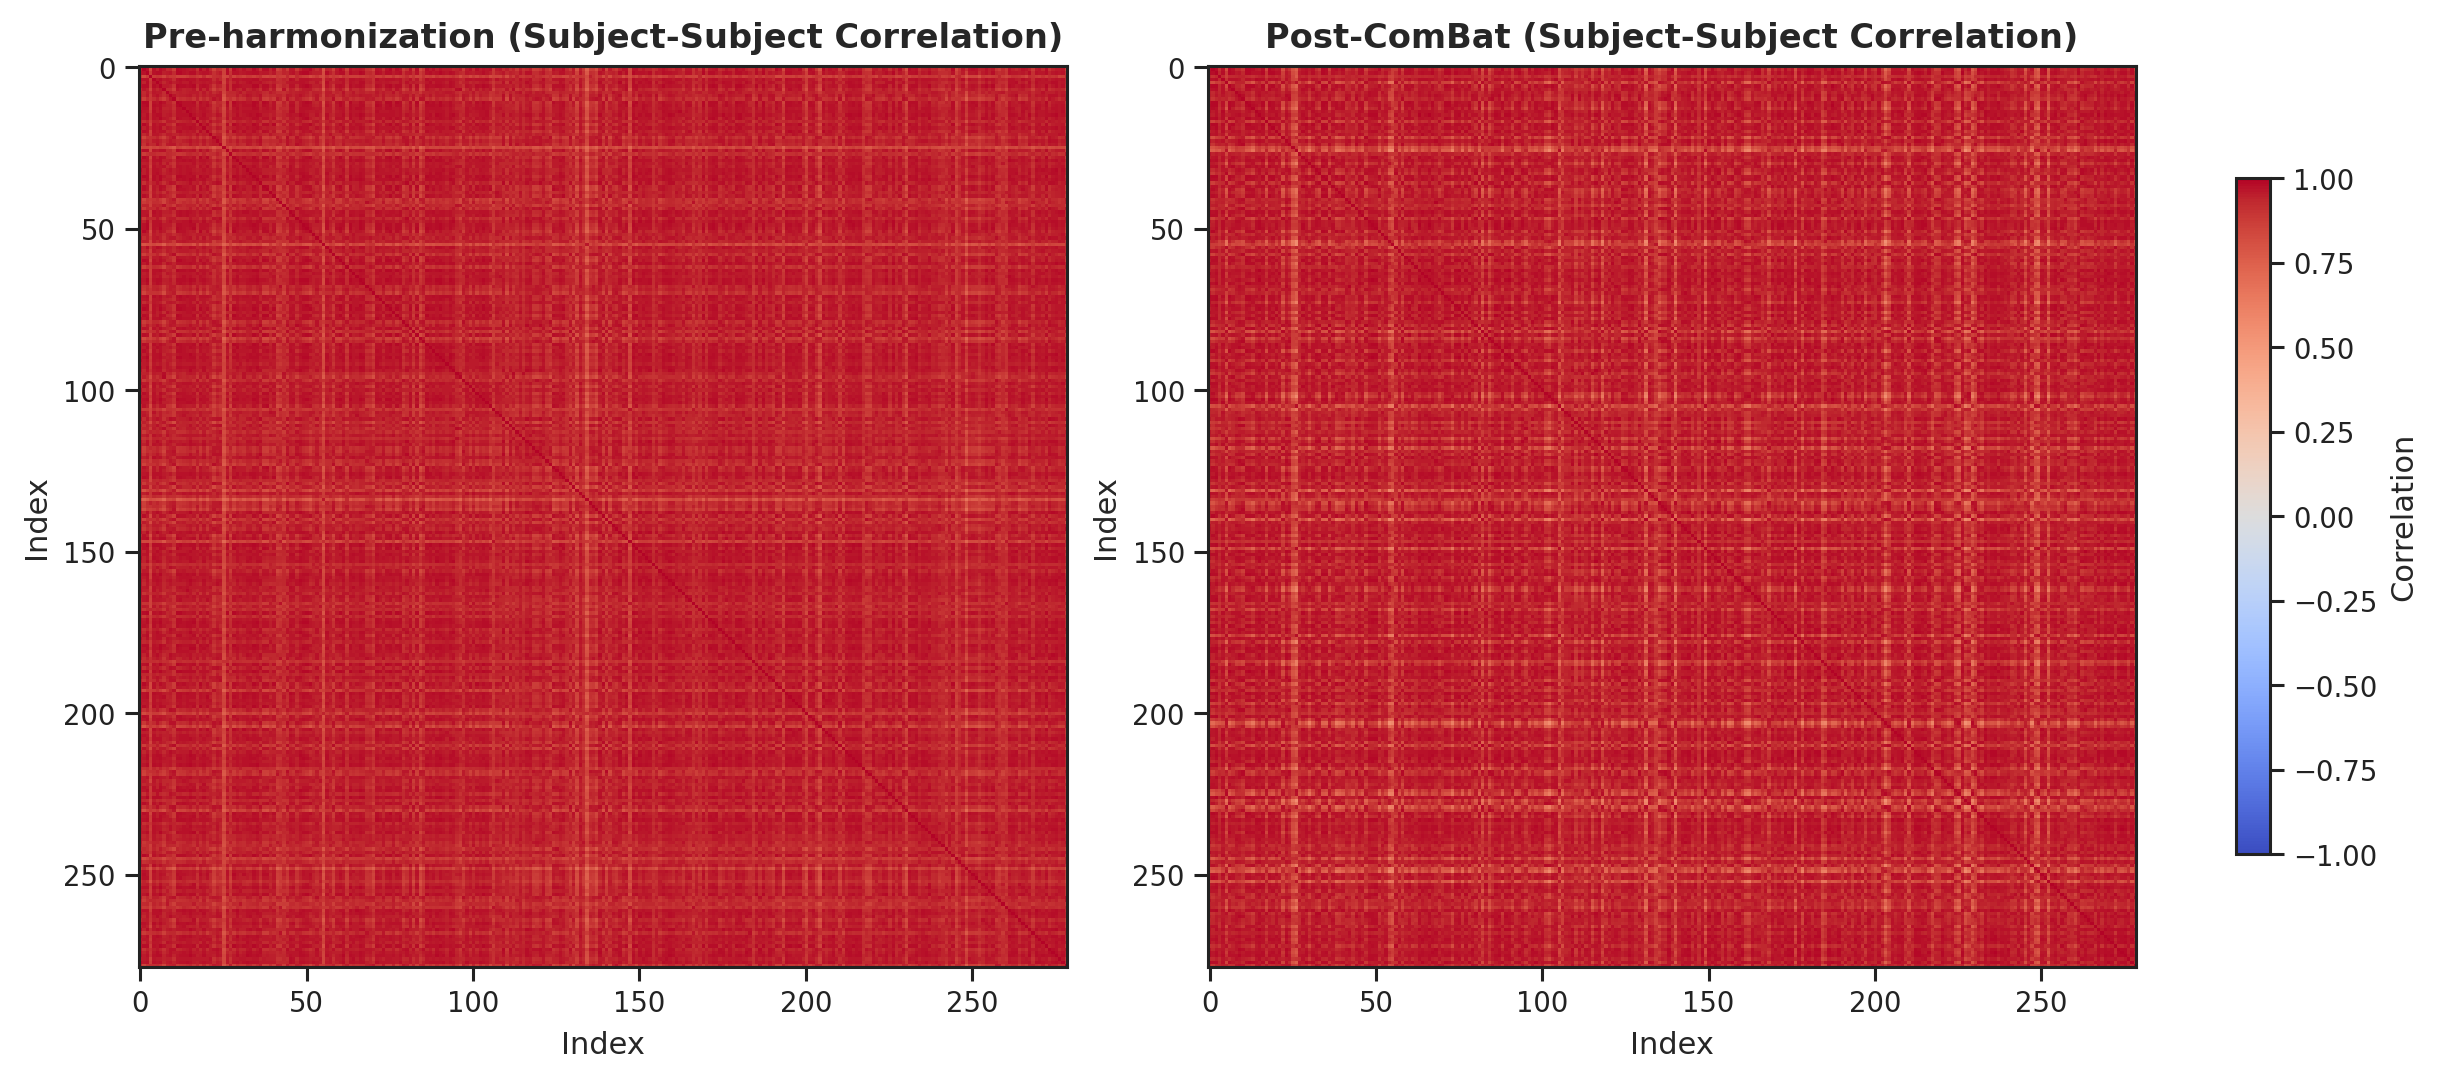

In [18]:
# Optional population-level region-wise subject-subject pre/post view
avail = available_regions(PREPOST, min_subjects=1)
REGION = int(avail.iloc[0]['parcel_idx'])
fig, axes = plot_region_covariance_side_by_side(PREPOST, region=REGION, mode='subject')
